# Inventory Risk Backtest

The MM strategy captures spread on round-trips but loses money on unhedged inventory that settles against us.
This notebook replays historical silver data through strategy variants to find parameters that reduce inventory risk.

**Features tested:**
1. Scaled per-ticker skew (widen proportional to position size)
2. Position age-based skew (widen as position ages)
3. Absolute exposure soft limit (stop opening new positions when total exposure is high)
4. Player-level correlated skew (track net position across thresholds for same player)

In [1]:
import io
import re
import sys
from dataclasses import dataclass, field
from datetime import date, timedelta
from typing import Any

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

sys.path.insert(0, '../..')
from app.events import (
    BookInvalidated, Event, MMFillEvent, MMQuoteEvent,
    OrderBookUpdate, TradeEvent,
)
from app.strategy.mm import maker_fee_cents, OrderSideState

s3 = boto3.client('s3')
BUCKET = 'prediction-markets-data'

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

## 1. Load silver data

In [2]:
def load_silver(event_type: str, dates: list[date]) -> pd.DataFrame:
    frames = []
    for d in dates:
        prefix = f'silver/kalshi_ws/{event_type}/date={d}/'
        pages = s3.get_paginator('list_objects_v2').paginate(Bucket=BUCKET, Prefix=prefix)
        keys = [o['Key'] for page in pages for o in page.get('Contents', [])]
        for k in keys:
            raw = s3.get_object(Bucket=BUCKET, Key=k)['Body'].read()
            frames.append(pd.read_parquet(io.BytesIO(raw)))
        if keys:
            print(f'  {event_type} {d}: {len(keys)} files')
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

# Load 7 days of data
today = date(2026, 4, 25)
dates = [today - timedelta(days=i) for i in range(7)]

print('Loading OrderBookUpdate...')
book_df = load_silver('OrderBookUpdate', dates)
print(f'\nLoading TradeEvent...')
trade_df = load_silver('TradeEvent', dates)

# Filter to KXNBAPTS only
book_df = book_df[book_df['market_ticker'].str.startswith('KXNBAPTS-')].copy()
trade_df = trade_df[trade_df['market_ticker'].str.startswith('KXNBAPTS-')].copy()

print(f'\nKXNBAPTS data:')
print(f'  OrderBookUpdate: {len(book_df):,} rows, {book_df["market_ticker"].nunique()} tickers')
print(f'  TradeEvent:      {len(trade_df):,} rows, {trade_df["market_ticker"].nunique()} tickers')
print(f'  Date range:      {book_df["t_receipt"].min():.0f} to {book_df["t_receipt"].max():.0f}')

Loading OrderBookUpdate...
  OrderBookUpdate 2026-04-25: 1105 files

Loading TradeEvent...
  TradeEvent 2026-04-25: 1096 files

KXNBAPTS data:
  OrderBookUpdate: 1,272,402 rows, 325 tickers
  TradeEvent:      13,757 rows, 240 tickers
  Date range:      1777083847 to 1777152528


## 2. Build event stream

In [3]:
# Convert DataFrames to sorted Event objects for replay
events: list[Event] = []

for _, row in book_df.iterrows():
    events.append(OrderBookUpdate(
        t_receipt=row['t_receipt'],
        market_ticker=row['market_ticker'],
        bid_yes=int(row['bid_yes']),
        ask_yes=int(row['ask_yes']),
        bid_size=int(row.get('bid_size', 10000)),
        ask_size=int(row.get('ask_size', 10000)),
    ))

for _, row in trade_df.iterrows():
    events.append(TradeEvent(
        t_receipt=row['t_receipt'],
        market_ticker=row['market_ticker'],
        side=row['side'],
        price=int(row['price']),
        size=int(row['size']),
    ))

events.sort(key=lambda e: e.t_receipt)
print(f'Total events: {len(events):,}')
print(f'  OrderBookUpdate: {sum(1 for e in events if isinstance(e, OrderBookUpdate)):,}')
print(f'  TradeEvent:      {sum(1 for e in events if isinstance(e, TradeEvent)):,}')

Total events: 1,286,159
  OrderBookUpdate: 1,272,402
  TradeEvent:      13,757


## 3. Look up settlements

In [4]:
# Get all unique KXNBAPTS tickers in the trade data
all_tickers = sorted(trade_df['market_ticker'].unique())
print(f'Looking up settlements for {len(all_tickers)} tickers...')

settlements: dict[str, str | None] = {}
for i, ticker in enumerate(all_tickers, 1):
    if i % 50 == 0 or i == len(all_tickers):
        print(f'  {i}/{len(all_tickers)}', end='\r')
    try:
        resp = requests.get(
            f'https://api.elections.kalshi.com/trade-api/v2/markets/{ticker}',
            timeout=10,
        )
        resp.raise_for_status()
        result = resp.json().get('market', {}).get('result')
        settlements[ticker] = result if result in ('yes', 'no') else None
    except Exception:
        settlements[ticker] = None

n_yes = sum(1 for v in settlements.values() if v == 'yes')
n_no = sum(1 for v in settlements.values() if v == 'no')
n_unk = sum(1 for v in settlements.values() if v is None)
print(f'\nSettlements: {n_yes} YES, {n_no} NO, {n_unk} unsettled')

Looking up settlements for 240 tickers...
  240/240
Settlements: 34 YES, 40 NO, 166 unsettled


## 4. Enhanced strategy (backtest variant)

Self-contained strategy with all 4 inventory risk features as config flags.
Mirrors production `MMStrategy` + `PaperOrderClient` exactly, with additions.

In [5]:
@dataclass
class BTConfig:
    """Backtest config — production defaults + new inventory risk params."""
    # --- existing production params ---
    min_spread_cents: int = 3
    min_edge_cents: int = 1
    max_position: int = 10
    max_aggregate_position: int = 200
    order_size: int = 1
    series_filter: str = 'KXNBAPTS-'
    skew_threshold: int = 3
    agg_skew_threshold: int = 5
    agg_skew_max: int = 15
    agg_skew_step_size: int = 5
    agg_skew_step_cents: int = 1
    skew_cents_per_contract: int = 0
    age_skew_interval_s: float = 0.0
    age_skew_step_cents: int = 1
    max_age_skew_cents: int = 10
    abs_exposure_soft_limit: int = 0
    use_player_skew: bool = False
    player_skew_cents_per_contract: int = 1
    min_trades_to_quote: int = 0
    allow_offsetting_on_tight_spread: bool = False
    # Queue model + dynamic sizing
    use_queue_model: bool = False
    queue_ahead_cap: int = 4
    use_dynamic_sizing: bool = False
    max_order_size: int = 2
    spread_size_threshold: int = 6


class BTPaperClient:
    """PaperOrderClient with optional queue-aware fill simulation."""

    def __init__(self, strategy: 'BTStrategy') -> None:
        self._strategy = strategy
        self._resting: dict[str, dict] = {}
        self._next_id: int = 0

    def place_limit(self, ticker, side, price_cents, size, t, queue_ahead=0):
        oid = f'bt-{self._next_id}'
        self._next_id += 1
        self._resting[oid] = {
            'ticker': ticker, 'side': side, 'price': price_cents,
            'remaining': size, 'queue_ahead': queue_ahead,
        }
        self._strategy.on_order_ack(ticker, side, oid)
        return oid

    def cancel(self, ticker, side, order_id, t):
        self._resting.pop(order_id, None)
        self._strategy.on_cancel_ack(ticker, side)

    def check_fill(self, trade: TradeEvent):
        use_queue = self._strategy._config.use_queue_model
        for oid in list(self._resting):
            info = self._resting.get(oid)
            if info is None or info['ticker'] != trade.market_ticker:
                continue
            matched = (
                (info['side'] == 'bid' and trade.side == 'no' and trade.price == info['price'])
                or (info['side'] == 'ask' and trade.side == 'yes' and trade.price == info['price'])
            )
            if not matched:
                continue
            queue = info.get('queue_ahead', 0) if use_queue else 0
            available = trade.size - queue
            if available <= 0:
                continue
            fs = min(info['remaining'], available)
            info['remaining'] -= fs
            if info['remaining'] <= 0:
                del self._resting[oid]
            self._strategy.on_fill(
                info['ticker'], info['side'], fs,
                info['remaining'] if oid in self._resting else 0,
                info['price'], oid, trade.t_receipt)
            return


class BTStrategy:
    """MMStrategy with all inventory risk features + queue model + dynamic sizing."""

    def __init__(self, config: BTConfig | None = None) -> None:
        self._config = config or BTConfig()
        self._client: BTPaperClient | None = None
        self._positions: dict[str, int] = {}
        self._aggregate_abs_position: int = 0
        self._agg_net_position: int = 0
        self._order_state: dict[str, dict[str, OrderSideState]] = {}
        self._last_quote: dict[str, tuple[int | None, int | None]] = {}
        self.fills: list[dict] = []
        self._position_opened_at: dict[str, float] = {}
        self._player_positions: dict[str, int] = {}
        self._trade_counts: dict[str, int] = {}
        self._current_update: OrderBookUpdate | None = None

    def set_client(self, client: BTPaperClient):
        self._client = client

    @staticmethod
    def _player_key(ticker: str) -> str | None:
        parts = ticker.split('-')
        return parts[2] if len(parts) >= 4 else None

    def _get_side(self, ticker, side) -> OrderSideState:
        if ticker not in self._order_state:
            self._order_state[ticker] = {'bid': OrderSideState(), 'ask': OrderSideState()}
        return self._order_state[ticker][side]

    def on_event(self, event: Event) -> None:
        if isinstance(event, OrderBookUpdate):
            self._on_book_update(event)
        elif isinstance(event, TradeEvent):
            self._on_trade(event)
        elif isinstance(event, BookInvalidated):
            self._on_book_invalidated(event)

    def on_order_ack(self, ticker, side, order_id):
        state = self._get_side(ticker, side)
        if state.state == 'pending':
            state.state = 'resting'
            state.order_id = order_id

    def on_cancel_ack(self, ticker, side):
        state = self._get_side(ticker, side)
        state.state = 'idle'
        state.order_id = None
        state.price = None

    def on_fill(self, ticker, side, fill_size, remaining_size, price, order_id, t):
        pos_before = self._positions.get(ticker, 0)
        delta = fill_size if side == 'bid' else -fill_size
        pos_after = pos_before + delta
        self._positions[ticker] = pos_after
        self._aggregate_abs_position = sum(abs(v) for v in self._positions.values())
        self._agg_net_position = sum(self._positions.values())
        if pos_before == 0 and pos_after != 0:
            self._position_opened_at[ticker] = t
        elif pos_after == 0:
            self._position_opened_at.pop(ticker, None)
        pk = self._player_key(ticker)
        if pk:
            self._player_positions[pk] = self._player_positions.get(pk, 0) + delta
        state = self._get_side(ticker, side)
        state.remaining_size = remaining_size
        if remaining_size == 0:
            state.state = 'idle'
            state.order_id = None
            state.price = None
        self.fills.append({
            't_receipt': t, 'market_ticker': ticker,
            'side': 'buy' if side == 'bid' else 'sell',
            'price': price, 'fill_size': fill_size,
            'position_before': pos_before, 'position_after': pos_after,
            'maker_fee': maker_fee_cents(price),
        })

    def _agg_skew_adjustment(self):
        net = self._agg_net_position
        cfg = self._config
        bid_adj, ask_adj = 0, 0
        suppress_bid, suppress_ask = False, False
        if net <= -cfg.agg_skew_max:
            suppress_ask = True
        elif net <= -cfg.agg_skew_threshold:
            steps = (-net - cfg.agg_skew_threshold) // cfg.agg_skew_step_size + 1
            ask_adj = steps * cfg.agg_skew_step_cents
        if net >= cfg.agg_skew_max:
            suppress_bid = True
        elif net >= cfg.agg_skew_threshold:
            steps = (net - cfg.agg_skew_threshold) // cfg.agg_skew_step_size + 1
            bid_adj = steps * cfg.agg_skew_step_cents
        return bid_adj, ask_adj, suppress_bid, suppress_ask

    def _compute_order_size(self, ticker, side, position, update):
        cfg = self._config
        if not cfg.use_dynamic_sizing:
            return cfg.order_size
        spread = update.ask_yes - update.bid_yes
        is_ext = (side == 'bid' and position > 0) or (side == 'ask' and position < 0)
        is_red = (side == 'bid' and position < 0) or (side == 'ask' and position > 0)
        sp_bonus = min(max(0.0, (spread - cfg.spread_size_threshold) / cfg.spread_size_threshold), 1.0)
        penalty = 0.25 * position ** 2 if is_ext else 0.0
        raw = 1.0 + sp_bonus - penalty
        size = max(1, min(int(raw), cfg.max_order_size))
        room = cfg.max_position - abs(position)
        size = min(size, max(room, 0))
        if is_red:
            size = min(size, abs(position))
        return max(1, size)

    def _on_book_update(self, update: OrderBookUpdate):
        ticker = update.market_ticker
        if not ticker.startswith(self._config.series_filter):
            return
        spread = update.ask_yes - update.bid_yes
        if spread <= 0:
            return
        position = self._positions.get(ticker, 0)
        mid = (update.bid_yes + update.ask_yes) // 2
        fee = maker_fee_cents(mid)
        net_half_spread = (spread // 2) - fee

        reason_no_bid: str | None = None
        reason_no_ask: str | None = None

        if net_half_spread < self._config.min_edge_cents:
            if self._config.allow_offsetting_on_tight_spread:
                if position >= 0:
                    reason_no_bid = 'spread_narrow'
                if position <= 0:
                    reason_no_ask = 'spread_narrow'
            else:
                reason_no_bid = 'spread_narrow'
                reason_no_ask = 'spread_narrow'
        if position >= self._config.max_position:
            reason_no_bid = 'pos_limit'
        if position <= -self._config.max_position:
            reason_no_ask = 'pos_limit'
        if self._aggregate_abs_position >= self._config.max_aggregate_position:
            if reason_no_bid is None:
                reason_no_bid = 'agg_limit'
            if reason_no_ask is None:
                reason_no_ask = 'agg_limit'
        if self._config.min_trades_to_quote > 0:
            if self._trade_counts.get(ticker, 0) < self._config.min_trades_to_quote:
                if reason_no_bid is None:
                    reason_no_bid = 'low_volume'
                if reason_no_ask is None:
                    reason_no_ask = 'low_volume'
        if (self._config.abs_exposure_soft_limit > 0
                and self._aggregate_abs_position >= self._config.abs_exposure_soft_limit):
            if position >= 0 and reason_no_bid is None:
                reason_no_bid = 'abs_soft_limit'
            if position <= 0 and reason_no_ask is None:
                reason_no_ask = 'abs_soft_limit'

        bid_price = update.bid_yes
        ask_price = update.ask_yes
        if self._config.skew_cents_per_contract > 0:
            if abs(position) >= self._config.skew_threshold:
                skew = abs(position) * self._config.skew_cents_per_contract
                if position > 0:
                    bid_price = max(1, bid_price - skew)
                else:
                    ask_price = min(99, ask_price + skew)
        else:
            if position > self._config.skew_threshold:
                bid_price = max(1, bid_price - 1)
            elif position < -self._config.skew_threshold:
                ask_price = min(99, ask_price + 1)
        if self._config.age_skew_interval_s > 0 and position != 0:
            opened_at = self._position_opened_at.get(ticker)
            if opened_at is not None:
                age_tiers = int((update.t_receipt - opened_at) / self._config.age_skew_interval_s)
                age_skew = min(age_tiers * self._config.age_skew_step_cents, self._config.max_age_skew_cents)
                if age_skew > 0:
                    if position > 0:
                        bid_price = max(1, bid_price - age_skew)
                    else:
                        ask_price = min(99, ask_price + age_skew)
        if self._config.use_player_skew:
            pk = self._player_key(ticker)
            if pk:
                pp = self._player_positions.get(pk, 0)
                if pp != 0:
                    p_skew = abs(pp) * self._config.player_skew_cents_per_contract
                    if pp > 0:
                        bid_price = max(1, bid_price - p_skew)
                    else:
                        ask_price = min(99, ask_price + p_skew)

        bid_adj, ask_adj, suppress_bid, suppress_ask = self._agg_skew_adjustment()
        if suppress_bid:
            reason_no_bid = reason_no_bid or 'agg_skew'
        elif bid_adj > 0:
            bid_price = max(1, bid_price - bid_adj)
        if suppress_ask:
            reason_no_ask = reason_no_ask or 'agg_skew'
        elif ask_adj > 0:
            ask_price = min(99, ask_price + ask_adj)

        desired_bid = bid_price if reason_no_bid is None else None
        desired_ask = ask_price if reason_no_ask is None else None

        last = self._last_quote.get(ticker)
        if last != (desired_bid, desired_ask):
            self._last_quote[ticker] = (desired_bid, desired_ask)

        self._current_update = update
        self._maybe_update_side(ticker, 'bid', desired_bid, update.t_receipt)
        self._maybe_update_side(ticker, 'ask', desired_ask, update.t_receipt)
        self._current_update = None

    def _on_trade(self, trade: TradeEvent):
        if not trade.market_ticker.startswith(self._config.series_filter):
            return
        self._trade_counts[trade.market_ticker] = self._trade_counts.get(trade.market_ticker, 0) + 1
        self._client.check_fill(trade)

    def _on_book_invalidated(self, event: BookInvalidated):
        ticker = event.market_ticker
        for side in ('bid', 'ask'):
            state = self._get_side(ticker, side)
            if state.state == 'resting':
                self._client.cancel(ticker, side, state.order_id or '', event.t_receipt)
            elif state.state == 'pending':
                state.state = 'idle'
                state.order_id = None
                state.price = None
        self._last_quote.pop(ticker, None)

    def _maybe_update_side(self, ticker, side, price, t):
        state = self._get_side(ticker, side)
        if price is None:
            if state.state == 'resting':
                state.state = 'cancel_pending'
                self._client.cancel(ticker, side, state.order_id or '', t)
            return
        if state.state == 'idle':
            update = self._current_update
            position = self._positions.get(ticker, 0)
            size = self._compute_order_size(ticker, side, position, update) if update else self._config.order_size
            queue_ahead = 0
            if update is not None:
                raw_depth = update.bid_size if side == 'bid' else update.ask_size
            queue_ahead = min(raw_depth, self._config.queue_ahead_cap) if self._config.use_queue_model else 0
            state.state = 'pending'
            state.price = price
            state.remaining_size = size
            self._client.place_limit(ticker, side, price, size, t, queue_ahead=queue_ahead)
        elif state.state == 'resting' and state.price != price:
            state.state = 'cancel_pending'
            self._client.cancel(ticker, side, state.order_id or '', t)

## 5. Backtest engine

In [6]:
def run_backtest(config: BTConfig, events: list[Event], settlements: dict) -> dict:
    """Replay events through strategy and compute full P&L."""
    strategy = BTStrategy(config)
    client = BTPaperClient(strategy)
    strategy.set_client(client)

    for event in events:
        strategy.on_event(event)

    if not strategy.fills:
        return {'name': '', 'fills': 0, 'round_trips': 0, 'realized_pnl': 0,
                'settled_pnl': 0, 'total_pnl': 0, 'win_rate': 0,
                'open_positions': 0, 'max_abs_exposure': 0, 'max_net_exposure': 0,
                'settled_wins': 0, 'settled_losses': 0}

    fills = pd.DataFrame(strategy.fills)

    # --- Round-trip P&L ---
    realized = 0
    rt_count = 0
    rt_wins = 0
    for ticker, g in fills.groupby('market_ticker'):
        buys = g[g['side'] == 'buy'].sort_values('t_receipt')
        sells = g[g['side'] == 'sell'].sort_values('t_receipt')
        pairs = min(len(buys), len(sells))
        for i in range(pairs):
            b, s = buys.iloc[i], sells.iloc[i]
            pnl = s['price'] - b['price'] - b['maker_fee'] - s['maker_fee']
            realized += pnl
            rt_count += 1
            if pnl > 0:
                rt_wins += 1

    # --- Open position P&L via settlements ---
    settled_pnl = 0
    settled_wins = 0
    settled_losses = 0
    open_count = 0
    for ticker, g in fills.groupby('market_ticker'):
        pos = g['position_after'].iloc[-1]
        if pos == 0:
            continue
        buys = g[g['side'] == 'buy'].sort_values('t_receipt')
        sells = g[g['side'] == 'sell'].sort_values('t_receipt')
        pairs = min(len(buys), len(sells))

        if pos > 0:
            unpaired = buys.iloc[pairs:]
        else:
            unpaired = sells.iloc[pairs:]

        settlement = settlements.get(ticker)
        if settlement is None:
            open_count += abs(pos)
            continue

        for _, fill in unpaired.iterrows():
            if pos > 0:  # long YES
                if settlement == 'yes':
                    p = (100 - fill['price']) - fill['maker_fee']
                else:
                    p = -(fill['price'] + fill['maker_fee'])
            else:  # short YES
                if settlement == 'no':
                    p = fill['price'] - fill['maker_fee']
                else:
                    p = -(100 - fill['price'] + fill['maker_fee'])
            settled_pnl += p
            if p > 0:
                settled_wins += 1
            else:
                settled_losses += 1

    # --- Exposure tracking ---
    # Replay positions to find max exposure
    positions: dict[str, int] = {}
    max_abs = 0
    max_net = 0
    for _, f in fills.iterrows():
        positions[f['market_ticker']] = f['position_after']
        abs_exp = sum(abs(v) for v in positions.values())
        net_exp = abs(sum(positions.values()))
        max_abs = max(max_abs, abs_exp)
        max_net = max(max_net, net_exp)

    return {
        'fills': len(fills),
        'round_trips': rt_count,
        'realized_pnl': realized,
        'win_rate': rt_wins / rt_count if rt_count > 0 else 0,
        'settled_pnl': settled_pnl,
        'total_pnl': realized + settled_pnl,
        'open_positions': open_count,
        'max_abs_exposure': max_abs,
        'max_net_exposure': max_net,
        'settled_wins': settled_wins,
        'settled_losses': settled_losses,
    }

## 6. Baseline

In [7]:
baseline_config = BTConfig()  # all production defaults
baseline = run_backtest(baseline_config, events, settlements)
baseline['name'] = 'baseline'

def print_result(r):
    print(f"  Fills:           {r['fills']}")
    print(f"  Round-trips:     {r['round_trips']}  (win rate: {r['win_rate']:.0%})")
    print(f"  Realized P&L:    {r['realized_pnl']:+.0f}c (${r['realized_pnl']/100:+.2f})")
    print(f"  Settled open:    {r['settled_pnl']:+.0f}c (${r['settled_pnl']/100:+.2f})  "
          f"[{r['settled_wins']}W / {r['settled_losses']}L]")
    print(f"  Total P&L:       {r['total_pnl']:+.0f}c (${r['total_pnl']/100:+.2f})")
    print(f"  Open (unsettled):{r['open_positions']} contracts")
    print(f"  Max abs exposure:{r['max_abs_exposure']}  Max net: {r['max_net_exposure']}")

print('=== BASELINE ===')
print_result(baseline)

=== BASELINE ===
  Fills:           445
  Round-trips:     123  (win rate: 73%)
  Realized P&L:    +1689c ($+16.89)
  Settled open:    -40c ($-0.40)  [27W / 91L]
  Total P&L:       +1649c ($+16.49)
  Open (unsettled):81 contracts
  Max abs exposure:199  Max net: 26


## 7. Sweep: Scaled per-ticker skew

Test `skew_threshold` x `skew_cents_per_contract` grid.

In [8]:
skew_results = []
for thresh in [1, 2, 3]:
    for cpc in [1, 2, 3, 4]:
        cfg = BTConfig(skew_threshold=thresh, skew_cents_per_contract=cpc)
        r = run_backtest(cfg, events, settlements)
        r['name'] = f'skew_t{thresh}_c{cpc}'
        r['skew_threshold'] = thresh
        r['skew_cents_per_contract'] = cpc
        skew_results.append(r)
        print(f"{r['name']:20s}  total={r['total_pnl']:+5.0f}c  "
              f"realized={r['realized_pnl']:+5.0f}c  settled={r['settled_pnl']:+5.0f}c  "
              f"fills={r['fills']}  max_abs={r['max_abs_exposure']}")

skew_df = pd.DataFrame(skew_results)
best_skew = skew_df.loc[skew_df['total_pnl'].idxmax()]
print(f"\nBest: {best_skew['name']} → {best_skew['total_pnl']:+.0f}c")

skew_t1_c1            total=+1028c  realized=+1437c  settled= -409c  fills=336  max_abs=114
skew_t1_c2            total= +941c  realized=+1314c  settled= -373c  fills=310  max_abs=111
skew_t1_c3            total= +906c  realized=+1243c  settled= -337c  fills=299  max_abs=108
skew_t1_c4            total= +906c  realized=+1243c  settled= -337c  fills=299  max_abs=108
skew_t2_c1            total=+1150c  realized=+1325c  settled= -175c  fills=372  max_abs=144
skew_t2_c2            total=+1187c  realized=+1344c  settled= -157c  fills=370  max_abs=142
skew_t2_c3            total=+1165c  realized=+1325c  settled= -160c  fills=372  max_abs=144
skew_t2_c4            total=+1166c  realized=+1325c  settled= -159c  fills=372  max_abs=144
skew_t3_c1            total=+1318c  realized=+1635c  settled= -317c  fills=420  max_abs=180
skew_t3_c2            total=+1348c  realized=+1635c  settled= -287c  fills=420  max_abs=180
skew_t3_c3            total=+1349c  realized=+1635c  settled= -286c  fills=420  

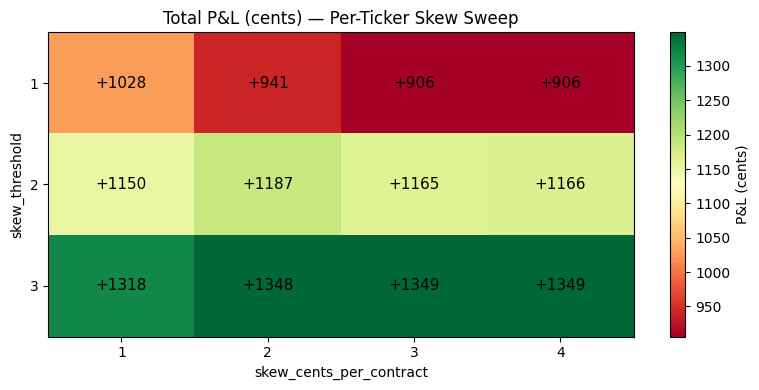

In [9]:
# Heatmap: skew_threshold x skew_cents_per_contract → total P&L
pivot = skew_df.pivot(index='skew_threshold', columns='skew_cents_per_contract', values='total_pnl')
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('skew_cents_per_contract')
ax.set_ylabel('skew_threshold')
ax.set_title('Total P&L (cents) — Per-Ticker Skew Sweep')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:+.0f}', ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax, label='P&L (cents)')
plt.tight_layout()
plt.show()

## 8. Sweep: Position age skew

Test `age_skew_interval_s` x `age_skew_step_cents` grid.

In [10]:
age_results = []
for interval in [300, 600, 900, 1800]:
    for step in [1, 2, 3]:
        cfg = BTConfig(age_skew_interval_s=interval, age_skew_step_cents=step)
        r = run_backtest(cfg, events, settlements)
        r['name'] = f'age_{interval}s_{step}c'
        r['interval'] = interval
        r['step'] = step
        age_results.append(r)
        print(f"{r['name']:20s}  total={r['total_pnl']:+5.0f}c  "
              f"realized={r['realized_pnl']:+5.0f}c  settled={r['settled_pnl']:+5.0f}c  "
              f"fills={r['fills']}  max_abs={r['max_abs_exposure']}")

age_df = pd.DataFrame(age_results)
best_age = age_df.loc[age_df['total_pnl'].idxmax()]
print(f"\nBest: {best_age['name']} → {best_age['total_pnl']:+.0f}c")

age_300s_1c           total=+1134c  realized=+1358c  settled= -224c  fills=337  max_abs=132
age_300s_2c           total=+1210c  realized=+1410c  settled= -200c  fills=335  max_abs=130
age_300s_3c           total=+1210c  realized=+1410c  settled= -200c  fills=336  max_abs=130
age_600s_1c           total=+1501c  realized=+1793c  settled= -292c  fills=348  max_abs=123
age_600s_2c           total=+1549c  realized=+1761c  settled= -212c  fills=351  max_abs=125
age_600s_3c           total=+1549c  realized=+1761c  settled= -212c  fills=352  max_abs=125
age_900s_1c           total=+1744c  realized=+1869c  settled= -125c  fills=378  max_abs=137
age_900s_2c           total=+1726c  realized=+1822c  settled=  -96c  fills=378  max_abs=137
age_900s_3c           total=+1761c  realized=+1853c  settled=  -92c  fills=378  max_abs=137
age_1800s_1c          total=+1764c  realized=+1996c  settled= -232c  fills=431  max_abs=162
age_1800s_2c          total=+1767c  realized=+1996c  settled= -229c  fills=431  

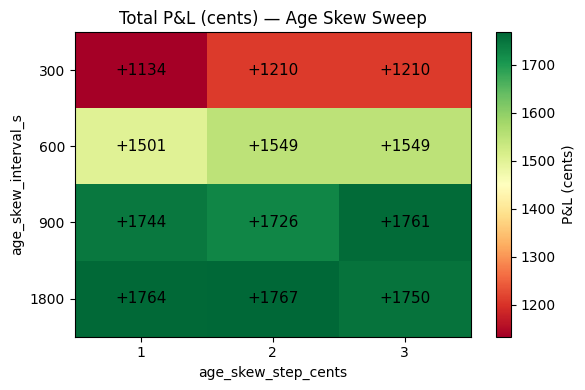

In [11]:
pivot = age_df.pivot(index='interval', columns='step', values='total_pnl')
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('age_skew_step_cents')
ax.set_ylabel('age_skew_interval_s')
ax.set_title('Total P&L (cents) — Age Skew Sweep')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:+.0f}', ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax, label='P&L (cents)')
plt.tight_layout()
plt.show()

## 9. Sweep: Absolute exposure soft limit

abs_limit_20          total=   -3c  realized=  +96c  settled=  -99c  fills=52  max_abs=31
abs_limit_30          total= +241c  realized= +385c  settled= -144c  fills=100  max_abs=31
abs_limit_40          total= +152c  realized= +507c  settled= -355c  fills=128  max_abs=41
abs_limit_50          total= +466c  realized= +492c  settled=  -26c  fills=148  max_abs=51
abs_limit_75          total= +476c  realized= +512c  settled=  -36c  fills=183  max_abs=75
abs_limit_100         total= +580c  realized= +875c  settled= -295c  fills=304  max_abs=102
abs_limit_150         total=+1255c  realized=+1237c  settled=  +18c  fills=362  max_abs=151

Best: abs_limit_150 → +1255c


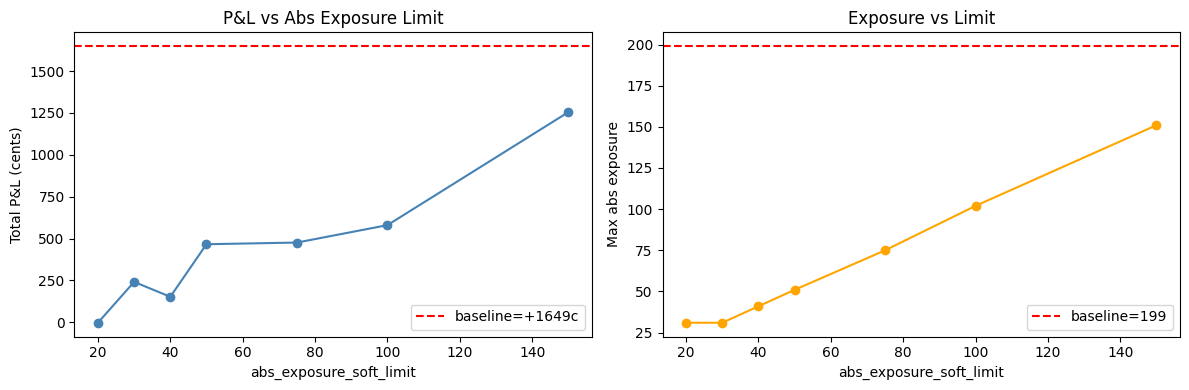

In [12]:
abs_results = []
for limit in [20, 30, 40, 50, 75, 100, 150]:
    cfg = BTConfig(abs_exposure_soft_limit=limit)
    r = run_backtest(cfg, events, settlements)
    r['name'] = f'abs_limit_{limit}'
    r['limit'] = limit
    abs_results.append(r)
    print(f"{r['name']:20s}  total={r['total_pnl']:+5.0f}c  "
          f"realized={r['realized_pnl']:+5.0f}c  settled={r['settled_pnl']:+5.0f}c  "
          f"fills={r['fills']}  max_abs={r['max_abs_exposure']}")

abs_df = pd.DataFrame(abs_results)
best_abs = abs_df.loc[abs_df['total_pnl'].idxmax()]
print(f"\nBest: {best_abs['name']} → {best_abs['total_pnl']:+.0f}c")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(abs_df['limit'], abs_df['total_pnl'], 'o-', color='steelblue')
ax.axhline(baseline['total_pnl'], color='red', linestyle='--', label=f"baseline={baseline['total_pnl']:+.0f}c")
ax.set_xlabel('abs_exposure_soft_limit')
ax.set_ylabel('Total P&L (cents)')
ax.set_title('P&L vs Abs Exposure Limit')
ax.legend()

ax = axes[1]
ax.plot(abs_df['limit'], abs_df['max_abs_exposure'], 'o-', color='orange')
ax.axhline(baseline['max_abs_exposure'], color='red', linestyle='--', label=f"baseline={baseline['max_abs_exposure']}")
ax.set_xlabel('abs_exposure_soft_limit')
ax.set_ylabel('Max abs exposure')
ax.set_title('Exposure vs Limit')
ax.legend()

plt.tight_layout()
plt.show()

## 10. Sweep: Player-level skew

In [13]:
player_results = []
for cpc in [1, 2, 3, 4]:
    cfg = BTConfig(use_player_skew=True, player_skew_cents_per_contract=cpc)
    r = run_backtest(cfg, events, settlements)
    r['name'] = f'player_skew_{cpc}c'
    r['player_cpc'] = cpc
    player_results.append(r)
    print(f"{r['name']:20s}  total={r['total_pnl']:+5.0f}c  "
          f"realized={r['realized_pnl']:+5.0f}c  settled={r['settled_pnl']:+5.0f}c  "
          f"fills={r['fills']}  max_abs={r['max_abs_exposure']}")

player_df = pd.DataFrame(player_results)
best_player = player_df.loc[player_df['total_pnl'].idxmax()]
print(f"\nBest: {best_player['name']} → {best_player['total_pnl']:+.0f}c")

player_skew_1c        total= +929c  realized=+1439c  settled= -510c  fills=342  max_abs=138
player_skew_2c        total= +844c  realized=+1324c  settled= -480c  fills=306  max_abs=130
player_skew_3c        total= +887c  realized=+1390c  settled= -503c  fills=301  max_abs=124
player_skew_4c        total= +879c  realized=+1329c  settled= -450c  fills=294  max_abs=124

Best: player_skew_1c → +929c


## 10b. Sweep: Minimum volume filter

Only quote on tickers that have seen at least N trades. This avoids illiquid markets
where we get filled on one side and never get offsetting flow.

min_vol_0             total=+1649c  realized=+1689c  settled=  -40c  fills=445  max_abs=199
min_vol_2             total=+1543c  realized=+1714c  settled= -171c  fills=431  max_abs=176
min_vol_3             total=+1633c  realized=+1816c  settled= -183c  fills=423  max_abs=166
min_vol_5             total=+1590c  realized=+1766c  settled= -176c  fills=417  max_abs=164
min_vol_8             total=+1616c  realized=+1814c  settled= -198c  fills=403  max_abs=156
min_vol_10            total=+1763c  realized=+1848c  settled=  -85c  fills=397  max_abs=152
min_vol_15            total=+1559c  realized=+1683c  settled= -124c  fills=387  max_abs=146
min_vol_20            total=+1847c  realized=+1756c  settled=  +91c  fills=381  max_abs=142

Best: min_vol_20 -> +1847c


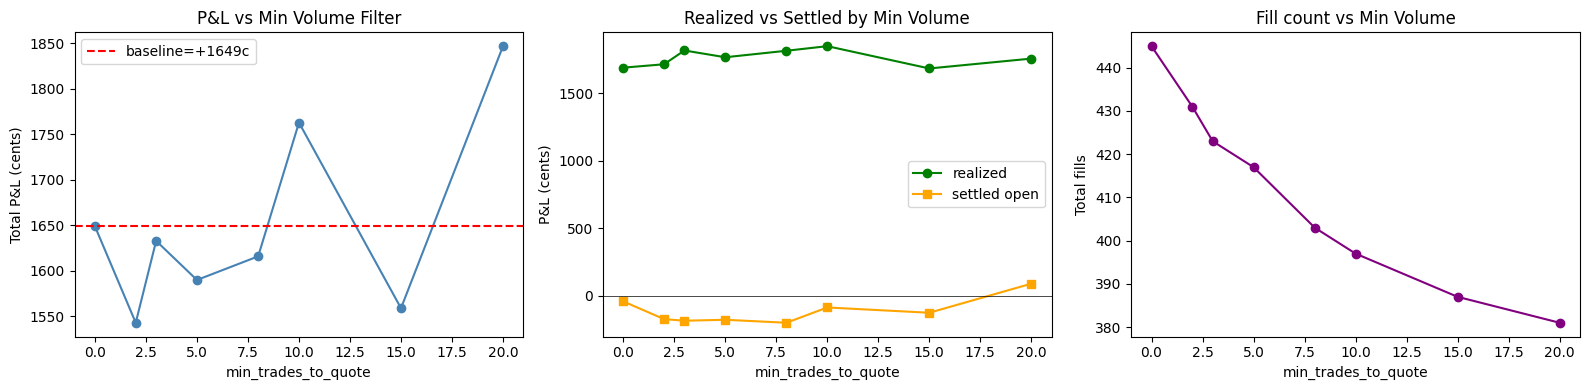

In [14]:
vol_results = []
for min_trades in [0, 2, 3, 5, 8, 10, 15, 20]:
    cfg = BTConfig(min_trades_to_quote=min_trades)
    r = run_backtest(cfg, events, settlements)
    r['name'] = f'min_vol_{min_trades}'
    r['min_trades'] = min_trades
    vol_results.append(r)
    print(f"{r['name']:20s}  total={r['total_pnl']:+5.0f}c  "
          f"realized={r['realized_pnl']:+5.0f}c  settled={r['settled_pnl']:+5.0f}c  "
          f"fills={r['fills']}  max_abs={r['max_abs_exposure']}")

vol_df = pd.DataFrame(vol_results)
best_vol = vol_df.loc[vol_df['total_pnl'].idxmax()]
print(f"\nBest: {best_vol['name']} -> {best_vol['total_pnl']:+.0f}c")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(vol_df['min_trades'], vol_df['total_pnl'], 'o-', color='steelblue')
ax.axhline(baseline['total_pnl'], color='red', linestyle='--', label=f"baseline={baseline['total_pnl']:+.0f}c")
ax.set_xlabel('min_trades_to_quote')
ax.set_ylabel('Total P&L (cents)')
ax.set_title('P&L vs Min Volume Filter')
ax.legend()

ax = axes[1]
ax.plot(vol_df['min_trades'], vol_df['realized_pnl'], 'o-', color='green', label='realized')
ax.plot(vol_df['min_trades'], vol_df['settled_pnl'], 's-', color='orange', label='settled open')
ax.set_xlabel('min_trades_to_quote')
ax.set_ylabel('P&L (cents)')
ax.set_title('Realized vs Settled by Min Volume')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)

ax = axes[2]
ax.plot(vol_df['min_trades'], vol_df['fills'], 'o-', color='purple')
ax.set_xlabel('min_trades_to_quote')
ax.set_ylabel('Total fills')
ax.set_title('Fill count vs Min Volume')

plt.tight_layout()
plt.show()

## 10c. Test: Offsetting orders on tight spreads

When carrying inventory and the spread compresses below min_edge, allow the
offsetting side to still post. Short? Bid stays active. Long? Ask stays active.
This prevents positions from being stuck when markets tighten.

In [15]:
offset_results = []
for flag in [False, True]:
    cfg = BTConfig(allow_offsetting_on_tight_spread=flag)
    r = run_backtest(cfg, events, settlements)
    r['name'] = f'offset_{"on" if flag else "off"}'
    r['flag'] = flag
    offset_results.append(r)
    print(f"{r['name']:20s}  total={r['total_pnl']:+5.0f}c  "
          f"realized={r['realized_pnl']:+5.0f}c  settled={r['settled_pnl']:+5.0f}c  "
          f"fills={r['fills']}  rt={r['round_trips']}  max_abs={r['max_abs_exposure']}")

# Now test with all_combined + offsetting
best_combined_base = BTConfig(
    skew_threshold=int(best_skew['skew_threshold']),
    skew_cents_per_contract=int(best_skew['skew_cents_per_contract']),
    age_skew_interval_s=float(best_age['interval']),
    age_skew_step_cents=int(best_age['step']),
    abs_exposure_soft_limit=int(best_abs['limit']),
    use_player_skew=True,
    player_skew_cents_per_contract=int(best_player['player_cpc']),
    min_trades_to_quote=int(best_vol['min_trades']),
)
for flag in [False, True]:
    cfg = BTConfig(
        skew_threshold=best_combined_base.skew_threshold,
        skew_cents_per_contract=best_combined_base.skew_cents_per_contract,
        age_skew_interval_s=best_combined_base.age_skew_interval_s,
        age_skew_step_cents=best_combined_base.age_skew_step_cents,
        abs_exposure_soft_limit=best_combined_base.abs_exposure_soft_limit,
        use_player_skew=best_combined_base.use_player_skew,
        player_skew_cents_per_contract=best_combined_base.player_skew_cents_per_contract,
        min_trades_to_quote=best_combined_base.min_trades_to_quote,
        allow_offsetting_on_tight_spread=flag,
    )
    r = run_backtest(cfg, events, settlements)
    r['name'] = f'all+offset_{"on" if flag else "off"}'
    r['flag'] = flag
    offset_results.append(r)
    print(f"{r['name']:20s}  total={r['total_pnl']:+5.0f}c  "
          f"realized={r['realized_pnl']:+5.0f}c  settled={r['settled_pnl']:+5.0f}c  "
          f"fills={r['fills']}  rt={r['round_trips']}  max_abs={r['max_abs_exposure']}")

print()
odf = pd.DataFrame(offset_results)
print(odf[['name', 'fills', 'round_trips', 'win_rate', 'realized_pnl',
           'settled_pnl', 'total_pnl', 'max_abs_exposure']].to_string(index=False))

offset_off            total=+1649c  realized=+1689c  settled=  -40c  fills=445  rt=123  max_abs=199
offset_on             total=+1492c  realized=+1760c  settled= -268c  fills=479  rt=151  max_abs=177
all+offset_off        total= +849c  realized=+1057c  settled= -208c  fills=232  rt=71  max_abs=90
all+offset_on         total= +817c  realized=+1179c  settled= -362c  fills=246  rt=79  max_abs=88

          name  fills  round_trips  win_rate  realized_pnl  settled_pnl  total_pnl  max_abs_exposure
    offset_off    445          123  0.731707          1689          -40       1649               199
     offset_on    479          151  0.662252          1760         -268       1492               177
all+offset_off    232           71  0.704225          1057         -208        849                90
 all+offset_on    246           79  0.670886          1179         -362        817                88


## 11. Combined: best params from each sweep

In [16]:
# Build combined config from best individual params
combined_configs = [
    ('baseline', BTConfig()),
    ('best_skew_only', BTConfig(
        skew_threshold=int(best_skew['skew_threshold']),
        skew_cents_per_contract=int(best_skew['skew_cents_per_contract']),
    )),
    ('best_age_only', BTConfig(
        age_skew_interval_s=float(best_age['interval']),
        age_skew_step_cents=int(best_age['step']),
    )),
    ('best_abs_only', BTConfig(
        abs_exposure_soft_limit=int(best_abs['limit']),
    )),
    ('best_player_only', BTConfig(
        use_player_skew=True,
        player_skew_cents_per_contract=int(best_player['player_cpc']),
    )),
    ('best_vol_only', BTConfig(
        min_trades_to_quote=int(best_vol['min_trades']),
    )),
    ('abs+vol', BTConfig(
        abs_exposure_soft_limit=int(best_abs['limit']),
        min_trades_to_quote=int(best_vol['min_trades']),
    )),
    ('all_combined', BTConfig(
        skew_threshold=int(best_skew['skew_threshold']),
        skew_cents_per_contract=int(best_skew['skew_cents_per_contract']),
        age_skew_interval_s=float(best_age['interval']),
        age_skew_step_cents=int(best_age['step']),
        abs_exposure_soft_limit=int(best_abs['limit']),
        use_player_skew=True,
        player_skew_cents_per_contract=int(best_player['player_cpc']),
        min_trades_to_quote=int(best_vol['min_trades']),
    )),
]

combined_results = []
for name, cfg in combined_configs:
    r = run_backtest(cfg, events, settlements)
    r['name'] = name
    combined_results.append(r)

cdf = pd.DataFrame(combined_results)
print(cdf[['name', 'fills', 'round_trips', 'win_rate', 'realized_pnl',
           'settled_pnl', 'total_pnl', 'max_abs_exposure', 'max_net_exposure',
           'settled_wins', 'settled_losses']].to_string(index=False))

            name  fills  round_trips  win_rate  realized_pnl  settled_pnl  total_pnl  max_abs_exposure  max_net_exposure  settled_wins  settled_losses
        baseline    445          123  0.731707          1689          -40       1649               199                26            27              91
  best_skew_only    420          122  0.745902          1635         -286       1349               180                26            19              89
   best_age_only    431          136  0.772059          1996         -229       1767               162                26            13              81
   best_abs_only    362          106  0.735849          1237           18       1255               151                26            27              85
best_player_only    342          102  0.784314          1439         -510        929               138                26            11              69
   best_vol_only    381          121  0.710744          1756           91       1847          

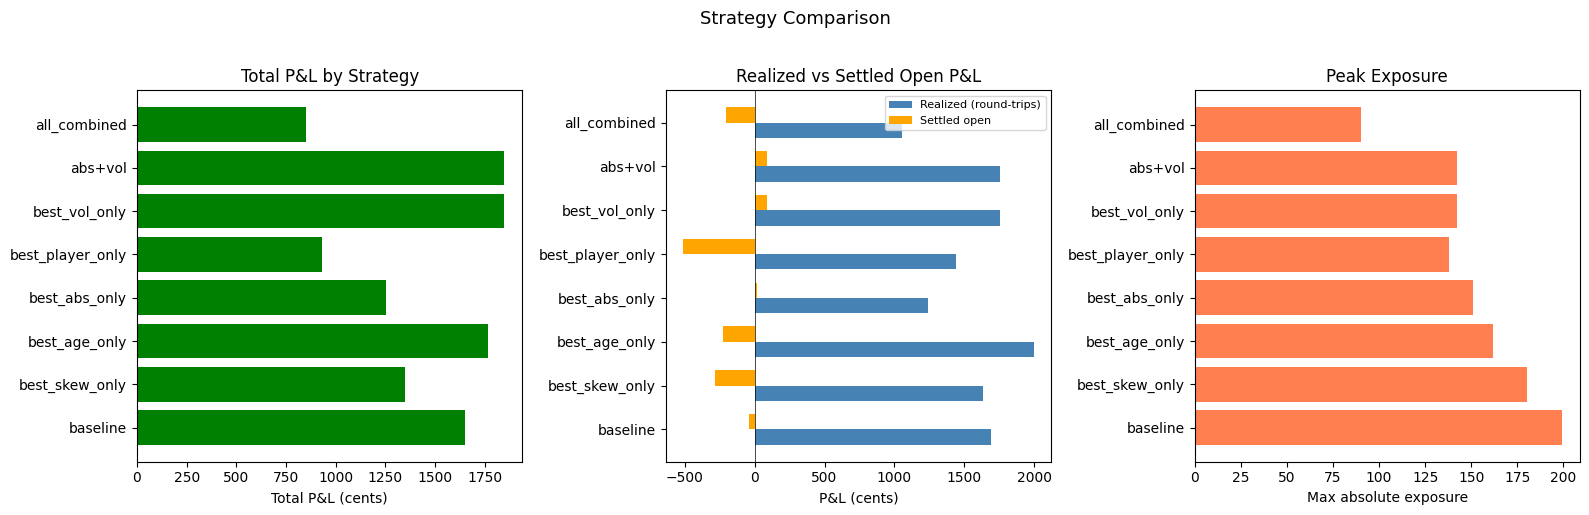

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total P&L comparison
ax = axes[0]
colors = ['red' if r['total_pnl'] < 0 else 'green' for r in combined_results]
ax.barh(range(len(combined_results)), [r['total_pnl'] for r in combined_results], color=colors)
ax.set_yticks(range(len(combined_results)))
ax.set_yticklabels([r['name'] for r in combined_results])
ax.set_xlabel('Total P&L (cents)')
ax.set_title('Total P&L by Strategy')
ax.axvline(0, color='black', linewidth=0.5)

# Realized vs settled breakdown
ax = axes[1]
x = range(len(combined_results))
w = 0.35
ax.barh([i - w/2 for i in x], [r['realized_pnl'] for r in combined_results],
        height=w, label='Realized (round-trips)', color='steelblue')
ax.barh([i + w/2 for i in x], [r['settled_pnl'] for r in combined_results],
        height=w, label='Settled open', color='orange')
ax.set_yticks(x)
ax.set_yticklabels([r['name'] for r in combined_results])
ax.set_xlabel('P&L (cents)')
ax.set_title('Realized vs Settled Open P&L')
ax.axvline(0, color='black', linewidth=0.5)
ax.legend(fontsize=8)

# Max exposure
ax = axes[2]
ax.barh(x, [r['max_abs_exposure'] for r in combined_results], color='coral')
ax.set_yticks(x)
ax.set_yticklabels([r['name'] for r in combined_results])
ax.set_xlabel('Max absolute exposure')
ax.set_title('Peak Exposure')

plt.suptitle('Strategy Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 12. Exposure over time: baseline vs best

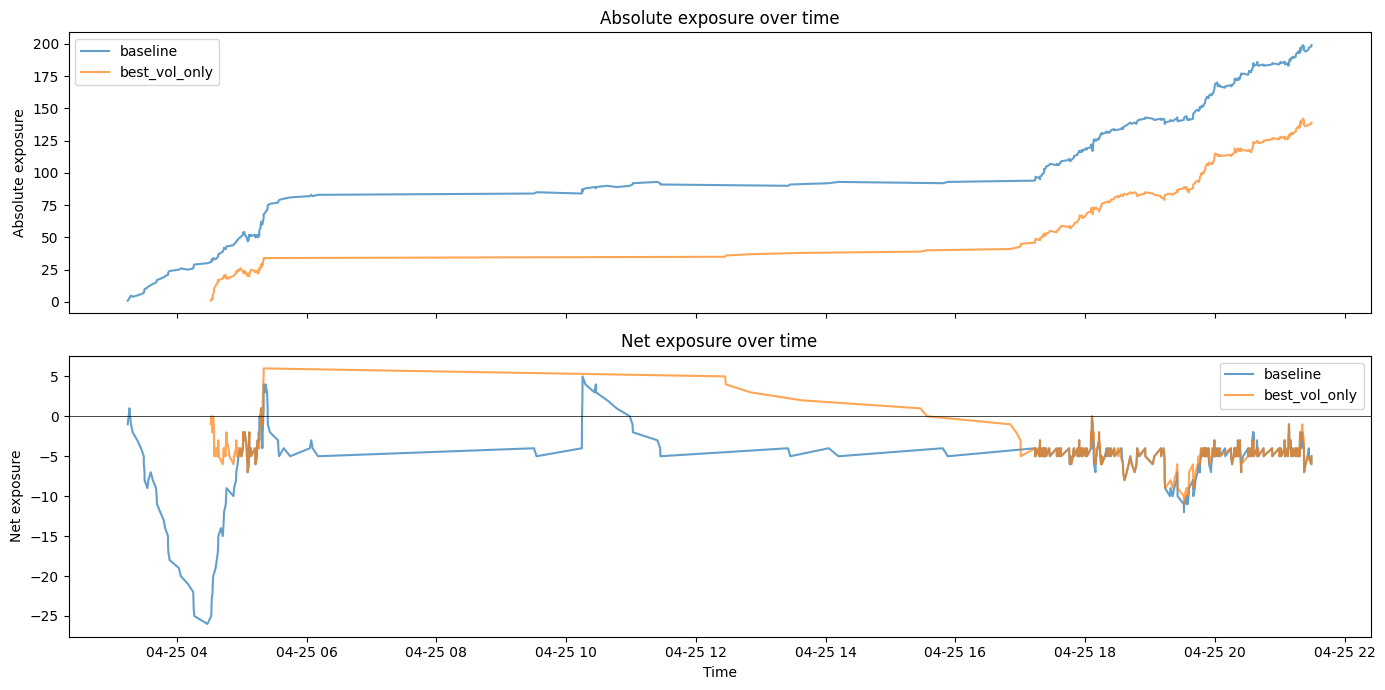

In [18]:
def exposure_timeseries(config: BTConfig, events: list[Event]) -> pd.DataFrame:
    """Replay and record exposure at each fill."""
    strategy = BTStrategy(config)
    client = BTPaperClient(strategy)
    strategy.set_client(client)

    records = []
    for event in events:
        strategy.on_event(event)
        # Check if new fills were added
        while len(records) < len(strategy.fills):
            f = strategy.fills[len(records)]
            abs_exp = sum(abs(v) for v in strategy._positions.values())
            net_exp = sum(strategy._positions.values())
            records.append({
                't': f['t_receipt'],
                'abs_exposure': abs_exp,
                'net_exposure': net_exp,
            })
    return pd.DataFrame(records)

# Find best combined config
best_combined_name = cdf.loc[cdf['total_pnl'].idxmax(), 'name']
best_combined_cfg = dict(combined_configs)[best_combined_name]

ts_baseline = exposure_timeseries(BTConfig(), events)
ts_best = exposure_timeseries(best_combined_cfg, events)

ts_baseline['t_dt'] = pd.to_datetime(ts_baseline['t'], unit='s', utc=True)
ts_best['t_dt'] = pd.to_datetime(ts_best['t'], unit='s', utc=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(ts_baseline['t_dt'], ts_baseline['abs_exposure'], alpha=0.7, label='baseline')
ax.plot(ts_best['t_dt'], ts_best['abs_exposure'], alpha=0.7, label=best_combined_name)
ax.set_ylabel('Absolute exposure')
ax.set_title('Absolute exposure over time')
ax.legend()

ax = axes[1]
ax.plot(ts_baseline['t_dt'], ts_baseline['net_exposure'], alpha=0.7, label='baseline')
ax.plot(ts_best['t_dt'], ts_best['net_exposure'], alpha=0.7, label=best_combined_name)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Net exposure')
ax.set_xlabel('Time')
ax.set_title('Net exposure over time')
ax.legend()

plt.tight_layout()
plt.show()

## 13. Summary & recommended config

In [19]:
print('=' * 70)
print('RECOMMENDED CONFIGURATION')
print('=' * 70)
print()
print(f'Best strategy: {best_combined_name}')
print()
best_r = cdf[cdf['name'] == best_combined_name].iloc[0]
base_r = cdf[cdf['name'] == 'baseline'].iloc[0]
print(f'                      Baseline    Best')
print(f'  Total P&L:       {base_r["total_pnl"]:+8.0f}c  {best_r["total_pnl"]:+8.0f}c')
print(f'  Realized:        {base_r["realized_pnl"]:+8.0f}c  {best_r["realized_pnl"]:+8.0f}c')
print(f'  Settled open:    {base_r["settled_pnl"]:+8.0f}c  {best_r["settled_pnl"]:+8.0f}c')
print(f'  Round-trips:     {base_r["round_trips"]:>8}   {best_r["round_trips"]:>8}')
print(f'  Win rate:        {base_r["win_rate"]:>8.0%}   {best_r["win_rate"]:>8.0%}')
print(f'  Max abs exposure:{base_r["max_abs_exposure"]:>8}   {best_r["max_abs_exposure"]:>8}')
print(f'  Settled W/L:     {base_r["settled_wins"]:.0f}/{base_r["settled_losses"]:.0f}'
      f'       {best_r["settled_wins"]:.0f}/{best_r["settled_losses"]:.0f}')
print()
print('Config params to apply:')
cfg = best_combined_cfg
print(f'  skew_threshold:               {cfg.skew_threshold}')
print(f'  skew_cents_per_contract:       {cfg.skew_cents_per_contract}')
print(f'  age_skew_interval_s:           {cfg.age_skew_interval_s}')
print(f'  age_skew_step_cents:           {cfg.age_skew_step_cents}')
print(f'  max_age_skew_cents:            {cfg.max_age_skew_cents}')
print(f'  abs_exposure_soft_limit:       {cfg.abs_exposure_soft_limit}')
print(f'  use_player_skew:               {cfg.use_player_skew}')
print(f'  player_skew_cents_per_contract: {cfg.player_skew_cents_per_contract}')

RECOMMENDED CONFIGURATION

Best strategy: best_vol_only

                      Baseline    Best
  Total P&L:          +1649c     +1847c
  Realized:           +1689c     +1756c
  Settled open:         -40c       +91c
  Round-trips:          123        121
  Win rate:             73%        71%
  Max abs exposure:     199        142
  Settled W/L:     27/91       24/71

Config params to apply:
  skew_threshold:               3
  skew_cents_per_contract:       0
  age_skew_interval_s:           0.0
  age_skew_step_cents:           1
  max_age_skew_cents:            10
  abs_exposure_soft_limit:       0
  use_player_skew:               False
  player_skew_cents_per_contract: 1


## 14. Queue model + dynamic sizing

Test queue-aware fill simulation and dynamic order sizing.
Queue model assumes we are at back of queue — only fill when trade.size > queue_depth.
Dynamic sizing posts up to max_order_size=2 when spread is wide and position is flat.

In [ ]:
results = []

# Sweep queue_ahead_cap to find realistic fill rate
print('=== Queue ahead cap sweep (with all features) ===')
for cap in [0, 1, 2, 3, 4, 5, 8, 10, 20]:
    cfg = BTConfig(
        skew_threshold=int(best_skew['skew_threshold']),
        skew_cents_per_contract=int(best_skew['skew_cents_per_contract']),
        age_skew_interval_s=float(best_age['interval']),
        age_skew_step_cents=int(best_age['step']),
        abs_exposure_soft_limit=int(best_abs['limit']),
        use_player_skew=True,
        player_skew_cents_per_contract=int(best_player['player_cpc']),
        min_trades_to_quote=int(best_vol['min_trades']),
        allow_offsetting_on_tight_spread=True,
        use_queue_model=True if cap > 0 else False,
        queue_ahead_cap=cap,
    )
    r = run_backtest(cfg, events, settlements)
    r['name'] = f'cap={cap}' if cap > 0 else 'no_queue'
    r['cap'] = cap
    results.append(r)
    print(f"  cap={cap:<3d}  total={r['total_pnl']:+6.0f}c  "
          f"realized={r['realized_pnl']:+6.0f}c  settled={r['settled_pnl']:+6.0f}c  "
          f"fills={r['fills']:>4}  rt={r['round_trips']:>3}  "
          f"max_abs={r['max_abs_exposure']:>4}")

print()

# Then test dynamic sizing with best cap
best_cap_df = pd.DataFrame(results)
best_cap = best_cap_df.loc[best_cap_df[best_cap_df['cap'] > 0]['total_pnl'].idxmax()]
print(f"Best queue cap: {int(best_cap['cap'])}")

print()
print('=== Dynamic sizing with best queue cap ===')
sizing_results = []
for max_sz in [1, 2]:
    cfg = BTConfig(
        skew_threshold=int(best_skew['skew_threshold']),
        skew_cents_per_contract=int(best_skew['skew_cents_per_contract']),
        age_skew_interval_s=float(best_age['interval']),
        age_skew_step_cents=int(best_age['step']),
        abs_exposure_soft_limit=int(best_abs['limit']),
        use_player_skew=True,
        player_skew_cents_per_contract=int(best_player['player_cpc']),
        min_trades_to_quote=int(best_vol['min_trades']),
        allow_offsetting_on_tight_spread=True,
        use_queue_model=True,
        queue_ahead_cap=int(best_cap['cap']),
        use_dynamic_sizing=max_sz > 1,
        max_order_size=max_sz,
    )
    r = run_backtest(cfg, events, settlements)
    r['name'] = f'queue(cap={int(best_cap["cap"])}) + size={max_sz}'
    sizing_results.append(r)
    print(f"  {r['name']:40s}  total={r['total_pnl']:+6.0f}c  "
          f"realized={r['realized_pnl']:+6.0f}c  settled={r['settled_pnl']:+6.0f}c  "
          f"fills={r['fills']:>4}  rt={r['round_trips']:>3}  "
          f"max_abs={r['max_abs_exposure']:>4}")

# Plot queue cap sweep
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cdf2 = pd.DataFrame(results)

ax = axes[0]
ax.plot(cdf2['cap'], cdf2['total_pnl'], 'o-', color='steelblue')
ax.set_xlabel('queue_ahead_cap')
ax.set_ylabel('Total P&L (cents)')
ax.set_title('P&L vs Queue Cap')

ax = axes[1]
ax.plot(cdf2['cap'], cdf2['fills'], 'o-', color='purple')
ax.set_xlabel('queue_ahead_cap')
ax.set_ylabel('Total fills')
ax.set_title('Fill count vs Queue Cap')

ax = axes[2]
ax.plot(cdf2['cap'], cdf2['round_trips'], 'o-', color='green')
ax.set_xlabel('queue_ahead_cap')
ax.set_ylabel('Round trips')
ax.set_title('Round trips vs Queue Cap')

plt.tight_layout()
plt.show()